# Channel-wise static/dynamic trial correlation

This notebook mirrors `run_channelwise_static_dynamic_correlation.py` and makes the correlation calculation directly inspectable.

For channel $c$, dynamic time $t_d$, and static time $t_s$, it computes

$$r(c,t_d,t_s)=\operatorname{corr}\left(X_{dynamic}[c,t_d,:], X_{static}[c,t_s,:]\right),$$

where `:` contains the matched stimuli/trials. Channels are **not** pooled into a population vector. Optionally, at every channel and static response time $t_s$, the standard last-frame static trial vector is residualized against the matched 2000 ms or 2250 ms static-condition trial vector at that same $t_s$. The residual trial vector is then correlated with each dynamic trial vector at $t_d$. The value 1 is expected only when two trial vectors are identical up to a positive affine transform. The real-data diagnostics below report the observed range and verify selected entries directly with `np.corrcoef`.

In [19]:
%matplotlib inline

from dataclasses import dataclass
import inspect
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml


ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
# Find the repository root whether the notebook starts from the repo or scripts folder.
PROJECT_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "config.yaml").exists()
)

with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)
# end with open

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])

from project_specific_utils import (
    channelwise_lag_curves,
    channelwise_regress_out,
    channelwise_static_dynamic_correlation,
    load_natraster,
    match_static_dynamic_rasters,
    match_timed_static_movie_rasters,
)
from useful_stuff.general_utils import TimeSeries

print(f"Project root: {PROJECT_ROOT}")
print(f"Environment: {ENV}")

Project root: /Users/tizianocausin/Desktop/static_dynamic
Environment: tiziano_mac_mini


In [57]:
@dataclass
class Cfg:
    static_exp_name: str = "red_20260726to27" # "baby1_260718to27"  #  
    dynamic_exp_name: str = "red_20260720to24" # "baby1_260716to24" #  
    image_prefix: str = "img_"
    image_2000ms_prefix: str = "img_2000ms_"
    image_2250ms_prefix: str = "img_2250ms_"
    dynamic_prefix: str = "vid_"
    # Set to None for raw data, or choose the delayed condition to remove.
    regress_out_condition: str | None = "2250ms" # None # "2000ms" #  
    regression_fit_intercept: bool = True
    # Inclusive, one-based MATLAB channel range.
    good_channels: tuple[int, int] | None = None #(84, 186) #(101, 109)#
    # Used only when good_channels is None; ranked by maximum video response.
    top_k: int | None = 20
    static_crop_ms: float | None = 1000
    new_fs: float = 100
    max_lag_ms: float = 700
    static_slice_ms: tuple[float, ...] = (0, 180, 250, 500, 750)
    # Video-time interval [start, end) searched for each correlation peak.
    peak_video_window_ms: tuple[float, float] | None = (2000, 3000)
    peak_histogram_bin_ms: float = 100
    video_final_frame_ms: float | None = 2500
# EOF


cfg = Cfg()
cfg

Cfg(static_exp_name='red_20260726to27', dynamic_exp_name='red_20260720to24', image_prefix='img_', image_2000ms_prefix='img_2000ms_', image_2250ms_prefix='img_2250ms_', dynamic_prefix='vid_', regress_out_condition='2250ms', regression_fit_intercept=True, good_channels=None, top_k=20, static_crop_ms=1000, new_fs=100, max_lag_ms=700, static_slice_ms=(0, 180, 250, 500, 750), peak_video_window_ms=(2000, 3000), peak_histogram_bin_ms=100, video_final_frame_ms=2500)

## Load and align matched trials

Static `img_` and dynamic `vid_` names are reduced to the same modality-independent stimulus identity. The static ordering is retained, and unmatched stimuli are removed before any correlation is calculated. Set `cfg.good_channels` for an explicit MATLAB channel range; otherwise, set `cfg.top_k` to retain the channels with the largest maximum raw video response across all video times and trials. The selected channels and downstream channel-wise plots remain ordered from highest to lowest excitation score. When `cfg.regress_out_condition` is `"2000ms"` or `"2250ms"`, the loader additionally aligns both delayed static conditions. For every channel $c$ and static response time $t_s$, it fits across trials $X_{last}(c,t_s,:) = \beta_{c,t_s}X_{delayed}(c,t_s,:) + \alpha_{c,t_s} + \epsilon(c,t_s,:)$ and passes the residual $\epsilon(c,t_s,:)$ to the dynamic correlation.

In [58]:
static_path = (
    Path(paths["data_path"])
    / "data"
    / f"{cfg.static_exp_name}_natraster_img.mat"
)
dynamic_path = (
    Path(paths["data_path"])
    / "data"
    / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
)

loaded_static, static_names = load_natraster(static_path)
loaded_dynamic, dynamic_names = load_natraster(dynamic_path)

supported_regression_conditions = ("2000ms", "2250ms")
if cfg.regress_out_condition is None:
    static_rasters, dynamic_rasters, shared_stimuli = (
        match_static_dynamic_rasters(
            loaded_static,
            static_names,
            loaded_dynamic,
            dynamic_names,
        )
    )
    regression_predictor_rasters = None
elif cfg.regress_out_condition in supported_regression_conditions:
    (
        static_rasters,
        dynamic_rasters,
        image_2000ms_rasters,
        image_2250ms_rasters,
        shared_stimuli,
        _,
    ) = match_timed_static_movie_rasters(
        loaded_static,
        static_names,
        loaded_dynamic,
        dynamic_names,
        image_prefix=cfg.image_prefix,
        image_2000ms_prefix=cfg.image_2000ms_prefix,
        image_2250ms_prefix=cfg.image_2250ms_prefix,
        movie_prefix=cfg.dynamic_prefix,
    )
    regression_predictor_rasters = {
        "2000ms": image_2000ms_rasters,
        "2250ms": image_2250ms_rasters,
    }[cfg.regress_out_condition]
else:
    raise ValueError(
        "regress_out_condition must be None, '2000ms', or '2250ms', got "
        f"{cfg.regress_out_condition!r}."
    )
# end if cfg.regress_out_condition is None

source_fs = 1000
n_available_channels = static_rasters.shape[0]
selected_excitation_scores = None
if cfg.good_channels is not None:
    first_channel, last_channel = cfg.good_channels
    if first_channel < 1 or last_channel < first_channel:
        raise ValueError(
            "good_channels must be an increasing one-based channel range."
        )
    # end if invalid good_channels order
    if last_channel > n_available_channels:
        raise ValueError(
            f"good_channels ends at {last_channel}, but the rasters contain "
            f"only {n_available_channels} channels."
        )
    # end if good_channels exceeds channel count
    channel_indices = np.arange(first_channel - 1, last_channel)
    channel_selection_description = (
        f"explicit MATLAB range {first_channel}-{last_channel}"
    )
elif cfg.top_k is not None:
    if not isinstance(cfg.top_k, int) or isinstance(cfg.top_k, bool):
        raise TypeError("top_k must be an integer or None.")
    # end if cfg.top_k type
    if not 1 <= cfg.top_k <= n_available_channels:
        raise ValueError(
            f"top_k must be between 1 and {n_available_channels}, got "
            f"{cfg.top_k}."
        )
    # end if cfg.top_k range

    # Excitement is the maximum raw video response across all video times
    # and matched trials.
    channel_excitation_scores = dynamic_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_excitation_scores)[
        -cfg.top_k:
    ][::-1]
    selected_excitation_scores = channel_excitation_scores[channel_indices]
    channel_selection_description = (
        f"top {cfg.top_k} video-responsive channels"
    )
else:
    channel_indices = np.arange(n_available_channels)
    channel_selection_description = "all available channels"
# end if cfg.good_channels is not None
channel_numbers = channel_indices + 1

if cfg.static_crop_ms is not None:
    static_end_index = int(round(cfg.static_crop_ms * source_fs / 1000))
    static_rasters = static_rasters[:, :static_end_index, :]
    if regression_predictor_rasters is not None:
        regression_predictor_rasters = regression_predictor_rasters[
            :, :static_end_index, :
        ]
    # end if regression_predictor_rasters is not None
# end if cfg.static_crop_ms

static_ts = TimeSeries(static_rasters[channel_indices], fs=source_fs)
dynamic_ts = TimeSeries(dynamic_rasters[channel_indices], fs=source_fs)
if regression_predictor_rasters is not None:
    regression_predictor_ts = TimeSeries(
        regression_predictor_rasters[channel_indices],
        fs=source_fs,
    )
# end if regression_predictor_rasters is not None
if cfg.new_fs != source_fs:
    static_ts.resample(cfg.new_fs)
    dynamic_ts.resample(cfg.new_fs)
    if regression_predictor_rasters is not None:
        regression_predictor_ts.resample(cfg.new_fs)
    # end if regression_predictor_rasters is not None
# end if cfg.new_fs

raw_static_array = static_ts.get_array()
dynamic_array = dynamic_ts.get_array()
if regression_predictor_rasters is None:
    static_array = raw_static_array
    static_response_label = "raw standard static"
else:
    static_array, regression_slopes, regression_intercepts, variance_explained = (
        channelwise_regress_out(
            regression_predictor_ts.get_array(),
            raw_static_array,
            fit_intercept=cfg.regression_fit_intercept,
        )
    )
    static_response_label = (
        f"standard static residual after {cfg.regress_out_condition} regression"
    )
    print(
        f"Mean channel-and-static-time variance removed by the "
        f"{cfg.regress_out_condition} condition: "
        f"{np.mean(variance_explained):.3f}"
    )

    # Audit the defining OLS property independently at every channel and t_s:
    # the predictor and fitted residual must be uncorrelated across trials.
    regression_predictor_array = regression_predictor_ts.get_array()
    predictor_centered = (
        regression_predictor_array
        - regression_predictor_array.mean(axis=2, keepdims=True)
    )
    residual_centered = (
        static_array - static_array.mean(axis=2, keepdims=True)
    )
    residual_predictor_numerators = np.sum(
        predictor_centered * residual_centered,
        axis=2,
    )
    residual_predictor_denominators = (
        np.linalg.norm(predictor_centered, axis=2)
        * np.linalg.norm(residual_centered, axis=2)
    )
    residual_predictor_correlations = np.full(
        residual_predictor_numerators.shape,
        np.nan,
        dtype=float,
    )
    np.divide(
        residual_predictor_numerators,
        residual_predictor_denominators,
        out=residual_predictor_correlations,
        where=residual_predictor_denominators > 0,
    )
    print(
        "Maximum |corr(delayed, residual)| across channel × t_s: "
        f"{np.nanmax(np.abs(residual_predictor_correlations)):.3e}"
    )
# end if regression_predictor_rasters is None

print(f"Matched trials: {len(shared_stimuli)}")
print(f"Channel selection: {channel_selection_description}")
print(f"Channels: {channel_numbers.tolist()}")
if selected_excitation_scores is not None:
    print(
        "Selected maximum video responses: "
        f"{selected_excitation_scores.tolist()}"
    )
# end if selected_excitation_scores is not None
print(
    f"Static array ({static_response_label}): "
    f"{static_array.shape} (channels, time, trials)"
)
print(f"Dynamic array: {dynamic_array.shape} (channels, time, trials)")

Mean channel-and-static-time variance removed by the 2250ms condition: 0.024
Maximum |corr(delayed, residual)| across channel × t_s: 1.027e-08
Matched trials: 100
Channel selection: top 20 video-responsive channels
Channels: [45, 3, 7, 57, 37, 5, 58, 31, 2, 19, 11, 24, 53, 56, 59, 63, 30, 46, 6, 64]
Selected maximum video responses: [0.3704761862754822, 0.35058823227882385, 0.3266666829586029, 0.2672727406024933, 0.242000013589859, 0.21222223341464996, 0.20000000298023224, 0.19866666197776794, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.1818181872367859, 0.18000000715255737, 0.18000000715255737]
Static array (standard static residual after 2250ms regression): (20, 100, 100) (channels, time, trials)
Dynamic array: (20, 350, 100) (channels, time, trials)


## Ranked channel excitation

When `top_k` is active, this plot shows the selected channels in the exact descending excitation order used by every downstream array and channel-wise plot. Each score is the maximum raw video response across all video times and matched trials.

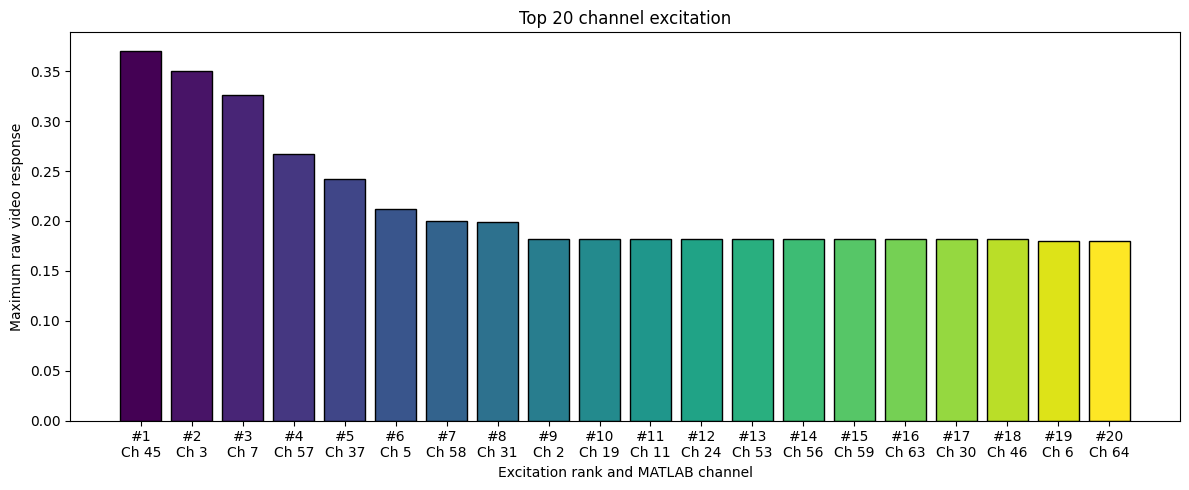

In [59]:
if selected_excitation_scores is not None:
    excitation_ranks = np.arange(1, len(channel_numbers) + 1)
    figure, axis = plt.subplots(figsize=(12, 5))
    axis.bar(
        excitation_ranks,
        selected_excitation_scores,
        color=plt.cm.viridis(
            np.linspace(0, 1, len(channel_numbers))
        ),
        edgecolor="black",
    )
    axis.set_xticks(excitation_ranks)
    axis.set_xticklabels([
        f"#{rank}\nCh {channel_number}"
        for rank, channel_number in zip(
            excitation_ranks,
            channel_numbers,
            strict=True,
        )
    ])
    axis.set(
        title=f"Top {cfg.top_k} channel excitation",
        xlabel="Excitation rank and MATLAB channel",
        ylabel="Maximum raw video response",
    )
    figure.tight_layout()
    plt.show()
else:
    print("Ranked excitation plot requires top_k channel selection.")
# end if selected_excitation_scores is not None


## Inspect and run the correlation implementation

The next cell prints the exact reusable correlation function used by both the script and this notebook. It mean-centers across trials independently at every channel/timepoint, then divides each dot product by the two trial-vector norms. If residualization is enabled, `static_array[c, t_s, :]` already contains the across-trial residual for that exact channel and static time before entering this function.

In [60]:
print(inspect.getsource(channelwise_static_dynamic_correlation))

def channelwise_static_dynamic_correlation(
        dynamic_rasters: np.ndarray,
        static_rasters: np.ndarray,
        ) -> tuple[np.ndarray, np.ndarray]:
    dynamic_rasters = np.asarray(dynamic_rasters, dtype=np.float64)
    static_rasters = np.asarray(static_rasters, dtype=np.float64)
    if dynamic_rasters.ndim != 3 or static_rasters.ndim != 3:
        raise ValueError(
            "Both rasters must have shape channels x time x matched trials."
        )
    # end if raster dimensions
    if dynamic_rasters.shape[0] != static_rasters.shape[0]:
        raise ValueError(
            "Static and dynamic rasters must contain the same channels."
        )
    # end if channel counts
    if dynamic_rasters.shape[2] != static_rasters.shape[2]:
        raise ValueError(
            "Static and dynamic rasters must contain the same matched trials."
        )
    # end if trial counts
    if dynamic_rasters.shape[2] < 2:
        raise ValueError("At least two matched trials are requir

In [61]:
channel_corr_matrices, average_corr_matrix = (
    channelwise_static_dynamic_correlation(
        dynamic_array,
        static_array,
    )
)

all_correlations = channel_corr_matrices[np.isfinite(channel_corr_matrices)]
quantile_levels = np.array([0, 0.01, 0.5, 0.99, 1.0])
quantile_values = np.quantile(all_correlations, quantile_levels)
print(
    "Channel matrices:",
    channel_corr_matrices.shape,
    "(channels, dynamic time, static time)",
)
print(
    f"Individual-channel range: {all_correlations.min():.6f} "
    f"to {all_correlations.max():.6f}"
)
print(
    f"Channel-average range: {np.nanmin(average_corr_matrix):.6f} "
    f"to {np.nanmax(average_corr_matrix):.6f}"
)
print("Quantiles:")
for level, value in zip(quantile_levels, quantile_values, strict=True):
    print(f"  {level:>5.0%}: {value:.6f}")
# end for level, value
print(
    "Values numerically close to +1:",
    np.count_nonzero(np.isclose(all_correlations, 1.0)),
    f"of {all_correlations.size}",
)

Channel matrices: (20, 350, 100) (channels, dynamic time, static time)
Individual-channel range: -0.415691 to 0.628286
Channel-average range: -0.087049 to 0.119599
Quantiles:
     0%: -0.415691
     1%: -0.218957
    50%: 0.004260
    99%: 0.324973
   100%: 0.628286
Values numerically close to +1: 0 of 700000


## Video-frame peak-timing histogram

For every channel, the code finds the largest correlation across all static times but only within the video-time interval `cfg.peak_video_window_ms`. The row of that windowed maximum is converted to milliseconds from video onset. The histogram therefore contains one peak timing per valid channel, expressed entirely in the video temporal reference frame. Set the interval to `None` to search the complete video.

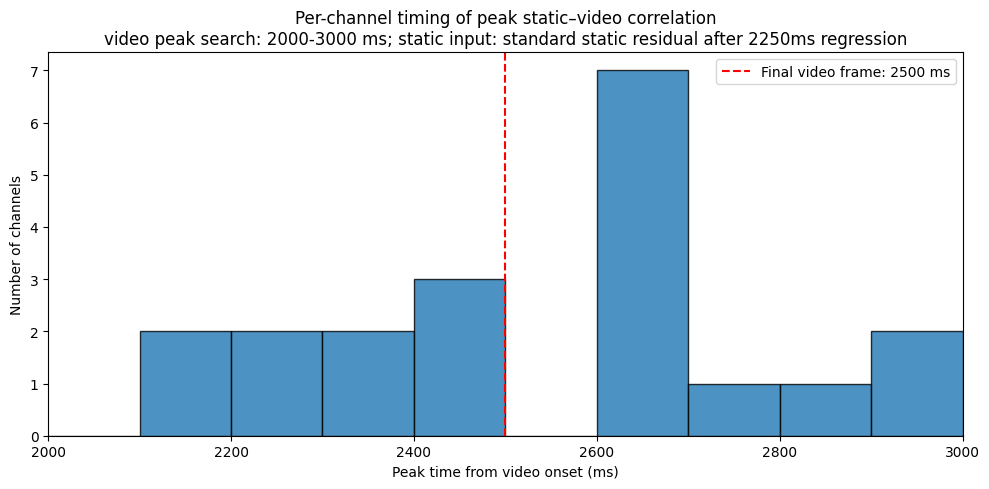

Peak video timing across 20 channels: median=2635 ms, range=2150-2920 ms; searched within 2000-3000 ms
  Ch 45: video=2630 ms, static=490 ms, r=0.628
  Ch 3: video=2460 ms, static=260 ms, r=0.540
  Ch 7: video=2340 ms, static=190 ms, r=0.493
  Ch 57: video=2840 ms, static=620 ms, r=0.482
  Ch 37: video=2920 ms, static=340 ms, r=0.437
  Ch 5: video=2680 ms, static=130 ms, r=0.379
  Ch 58: video=2290 ms, static=530 ms, r=0.509
  Ch 31: video=2670 ms, static=380 ms, r=0.548
  Ch 2: video=2250 ms, static=250 ms, r=0.424
  Ch 19: video=2780 ms, static=850 ms, r=0.405
  Ch 11: video=2180 ms, static=80 ms, r=0.421
  Ch 24: video=2920 ms, static=970 ms, r=0.375
  Ch 53: video=2670 ms, static=970 ms, r=0.455
  Ch 56: video=2690 ms, static=830 ms, r=0.452
  Ch 59: video=2640 ms, static=180 ms, r=0.479
  Ch 63: video=2660 ms, static=460 ms, r=0.399
  Ch 30: video=2370 ms, static=230 ms, r=0.410
  Ch 46: video=2440 ms, static=150 ms, r=0.429
  Ch 6: video=2410 ms, static=810 ms, r=0.406
  Ch 64: v

In [62]:
if cfg.peak_histogram_bin_ms <= 0:
    raise ValueError("peak_histogram_bin_ms must be positive.")
# end if cfg.peak_histogram_bin_ms <= 0

# Convert the configured video-time interval [start, end) to rows of the
# correlation matrices. Static time remains unrestricted.
video_duration_ms = channel_corr_matrices.shape[1] * 1000 / cfg.new_fs
if cfg.peak_video_window_ms is None:
    peak_window_start_ms = 0
    peak_window_end_ms = video_duration_ms
else:
    peak_window_start_ms, peak_window_end_ms = cfg.peak_video_window_ms
    if not (
            np.isfinite(peak_window_start_ms)
            and np.isfinite(peak_window_end_ms)
            ):
        raise ValueError("peak_video_window_ms must contain finite values.")
    # end if peak window is not finite
    if not 0 <= peak_window_start_ms < peak_window_end_ms <= video_duration_ms:
        raise ValueError(
            "peak_video_window_ms must satisfy "
            f"0 <= start < end <= {video_duration_ms:g} ms, got "
            f"{cfg.peak_video_window_ms}."
        )
    # end if peak window bounds
# end if cfg.peak_video_window_ms is None

peak_window_start_index = int(
    np.ceil(peak_window_start_ms * cfg.new_fs / 1000)
)
peak_window_end_index = int(
    np.ceil(peak_window_end_ms * cfg.new_fs / 1000)
)
if peak_window_start_index >= peak_window_end_index:
    raise ValueError(
        "peak_video_window_ms contains no samples at the resampled rate."
    )
# end if peak window contains no samples
peak_window_label = (
    f"{peak_window_start_ms:g}-{peak_window_end_ms:g} ms"
)
peak_window_matrices = channel_corr_matrices[
    :, peak_window_start_index:peak_window_end_index, :
]

# Exclude channels whose correlation matrix is undefined inside the window.
valid_peak_channels = np.any(
    np.isfinite(peak_window_matrices), axis=(1, 2)
)
valid_channel_matrices = peak_window_matrices[valid_peak_channels]
if valid_channel_matrices.shape[0] == 0:
    raise ValueError("No channel contains a finite correlation peak.")
# end if valid_channel_matrices.shape[0] == 0

# Flatten only the windowed video and complete static time axes, then
# recover the video-time row of each channel's largest correlation.
finite_channel_matrices = np.where(
    np.isfinite(valid_channel_matrices),
    valid_channel_matrices,
    -np.inf,
)
peak_flat_indices = np.argmax(
    finite_channel_matrices.reshape(valid_channel_matrices.shape[0], -1),
    axis=1,
)
peak_video_indices_in_window, peak_static_indices = np.unravel_index(
    peak_flat_indices,
    valid_channel_matrices.shape[1:],
)
peak_video_indices = (
    peak_video_indices_in_window + peak_window_start_index
)
peak_video_times_ms = peak_video_indices * 1000 / cfg.new_fs
peak_static_times_ms = peak_static_indices * 1000 / cfg.new_fs
valid_channel_numbers = channel_numbers[valid_peak_channels]
peak_correlations = valid_channel_matrices[
    np.arange(valid_channel_matrices.shape[0]),
    peak_video_indices_in_window,
    peak_static_indices,
]

histogram_edges_ms = np.arange(
    peak_window_start_ms,
    peak_window_end_ms,
    cfg.peak_histogram_bin_ms,
)
histogram_edges_ms = np.append(
    histogram_edges_ms,
    peak_window_end_ms,
)
figure, axis = plt.subplots(figsize=(10, 5))
axis.hist(
    peak_video_times_ms,
    bins=histogram_edges_ms,
    color="tab:blue",
    edgecolor="black",
    alpha=0.8,
)
if (
        cfg.video_final_frame_ms is not None
        and peak_window_start_ms
        <= cfg.video_final_frame_ms
        <= peak_window_end_ms
        ):
    axis.axvline(
        cfg.video_final_frame_ms,
        color="red",
        linestyle="--",
        label=f"Final video frame: {cfg.video_final_frame_ms:g} ms",
    )
    axis.legend()
# end if final video frame is inside peak window
axis.set(
    title=(
        "Per-channel timing of peak static–video correlation\n"
        f"video peak search: {peak_window_label}; "
        f"static input: {static_response_label}"
    ),
    xlabel="Peak time from video onset (ms)",
    ylabel="Number of channels",
    xlim=(peak_window_start_ms, peak_window_end_ms),
)
figure.tight_layout()
plt.show()

print(
    f"Peak video timing across {len(peak_video_times_ms)} channels: "
    f"median={np.median(peak_video_times_ms):g} ms, "
    f"range={peak_video_times_ms.min():g}-"
    f"{peak_video_times_ms.max():g} ms; "
    f"searched within {peak_window_label}"
)
for channel_number, video_time_ms, static_time_ms, correlation in zip(
        valid_channel_numbers,
        peak_video_times_ms,
        peak_static_times_ms,
        peak_correlations,
        strict=True,
        ):
    print(
        f"  Ch {channel_number}: video={video_time_ms:g} ms, "
        f"static={static_time_ms:g} ms, r={correlation:.3f}"
    )
# end for channel peak


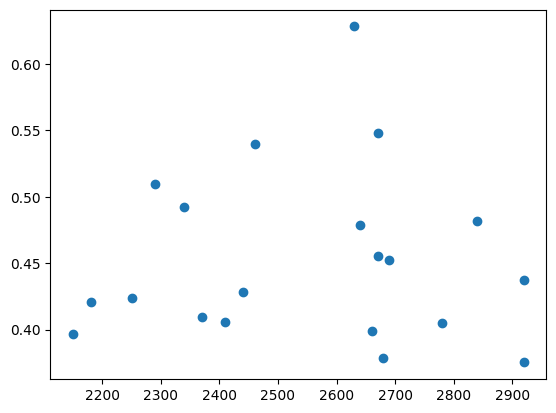

In [63]:
plt.scatter(peak_video_times_ms, peak_correlations)

## Average correlation matrix

The color limits below use the observed channel-average magnitude, and the exact range is included in the title. This avoids implying that the data reach ±1.

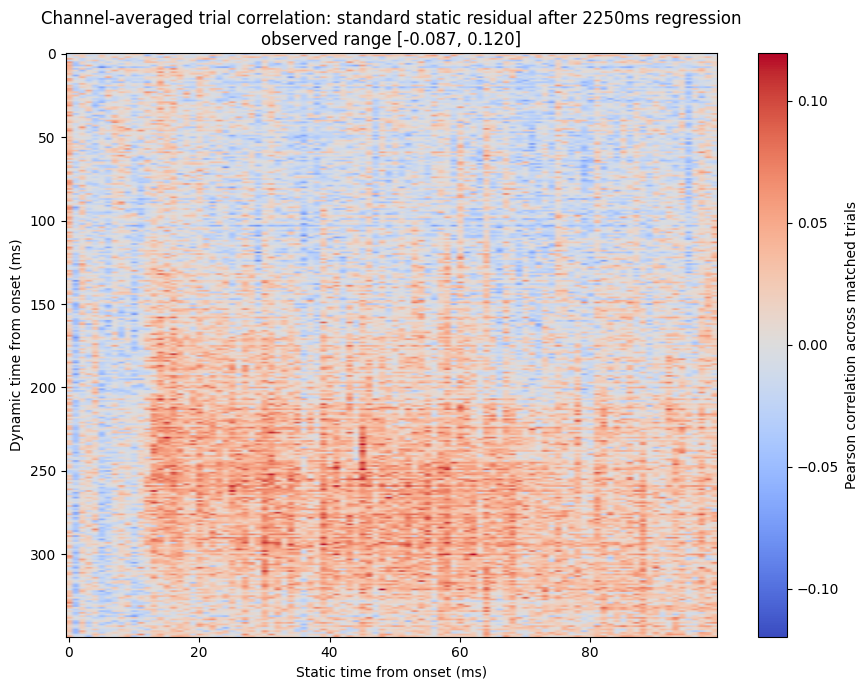

In [64]:
static_times_ms = np.arange(static_array.shape[1]) * 1000 / cfg.new_fs
dynamic_times_ms = np.arange(dynamic_array.shape[1]) * 1000 / cfg.new_fs
matrix_limit = np.nanmax(np.abs(average_corr_matrix))

figure, axis = plt.subplots(figsize=(9, 7))
image = axis.imshow(
    average_corr_matrix,
    # origin="lower",
    aspect="auto",
    # extent=(
    #     static_times_ms[0],
    #     static_times_ms[-1],
    #     dynamic_times_ms[0],
    #     dynamic_times_ms[-1],
    # ),
    cmap="coolwarm",
    vmin=-matrix_limit,
    vmax=matrix_limit,
)
axis.set(
    title=(
        f"Channel-averaged trial correlation: {static_response_label}\n"
        f"observed range [{np.nanmin(average_corr_matrix):.3f}, "
        f"{np.nanmax(average_corr_matrix):.3f}]"
    ),
    xlabel="Static time from onset (ms)",
    ylabel="Dynamic time from onset (ms)",
)
colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Pearson correlation across matched trials")
figure.tight_layout()
plt.show()

## Direct `np.corrcoef` audit of the largest coefficient

This extracts the two original 100-trial vectors at the location of the largest channel-wise coefficient and recomputes it independently.

Channel: 45
Dynamic time: 2630 ms
Static time: 490 ms
Stored vectorized correlation: 0.628285862278
Direct np.corrcoef result:      0.628285862278
Absolute difference:            1.110e-16


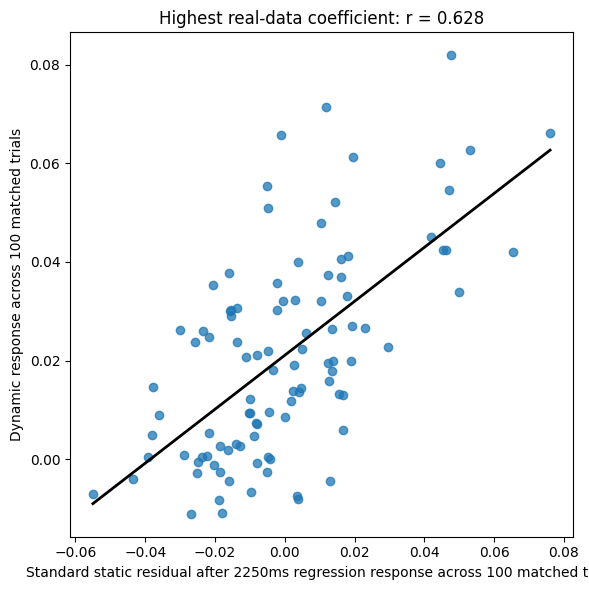

In [45]:
max_index = np.unravel_index(
    np.nanargmax(channel_corr_matrices),
    channel_corr_matrices.shape,
)
channel_index, dynamic_index, static_index = max_index
dynamic_trial_vector = dynamic_array[channel_index, dynamic_index, :]
static_trial_vector = static_array[channel_index, static_index, :]
stored_correlation = channel_corr_matrices[max_index]
direct_correlation = np.corrcoef(
    dynamic_trial_vector,
    static_trial_vector,
)[0, 1]

print(f"Channel: {channel_numbers[channel_index]}")
print(f"Dynamic time: {dynamic_times_ms[dynamic_index]:g} ms")
print(f"Static time: {static_times_ms[static_index]:g} ms")
print(f"Stored vectorized correlation: {stored_correlation:.12f}")
print(f"Direct np.corrcoef result:      {direct_correlation:.12f}")
print(f"Absolute difference:            {abs(stored_correlation - direct_correlation):.3e}")
assert np.allclose(stored_correlation, direct_correlation)

slope, intercept = np.polyfit(static_trial_vector, dynamic_trial_vector, 1)
fit_x = np.linspace(static_trial_vector.min(), static_trial_vector.max(), 100)
figure, axis = plt.subplots(figsize=(6, 6))
axis.scatter(static_trial_vector, dynamic_trial_vector, alpha=0.75)
axis.plot(fit_x, slope * fit_x + intercept, color="black", linewidth=2)
axis.set(
    title=f"Highest real-data coefficient: r = {direct_correlation:.3f}",
    xlabel=(
        f"{static_response_label.capitalize()} response across "
        f"{len(shared_stimuli)} matched trials"
    ),
    ylabel=f"Dynamic response across {len(shared_stimuli)} matched trials",
)
figure.tight_layout()
plt.show()

## Random-entry verification

Twenty matrix entries are independently recomputed from their original trial vectors. The assertion requires agreement to numerical precision.

In [46]:
rng = np.random.default_rng(7)
audit_errors = []
for _ in range(20):
    channel_index = rng.integers(channel_corr_matrices.shape[0])
    dynamic_index = rng.integers(channel_corr_matrices.shape[1])
    static_index = rng.integers(channel_corr_matrices.shape[2])
    direct_value = np.corrcoef(
        dynamic_array[channel_index, dynamic_index, :],
        static_array[channel_index, static_index, :],
    )[0, 1]
    stored_value = channel_corr_matrices[
        channel_index,
        dynamic_index,
        static_index,
    ]
    audit_errors.append(abs(direct_value - stored_value))
# end for audit entry

print(f"Maximum error over 20 direct checks: {max(audit_errors):.3e}")
assert max(audit_errors) < 1e-12

Maximum error over 20 direct checks: 1.388e-16


## Static-time slices: every channel's dynamic timecourse

Each thin line is one channel. The thick black line is the arithmetic channel average.

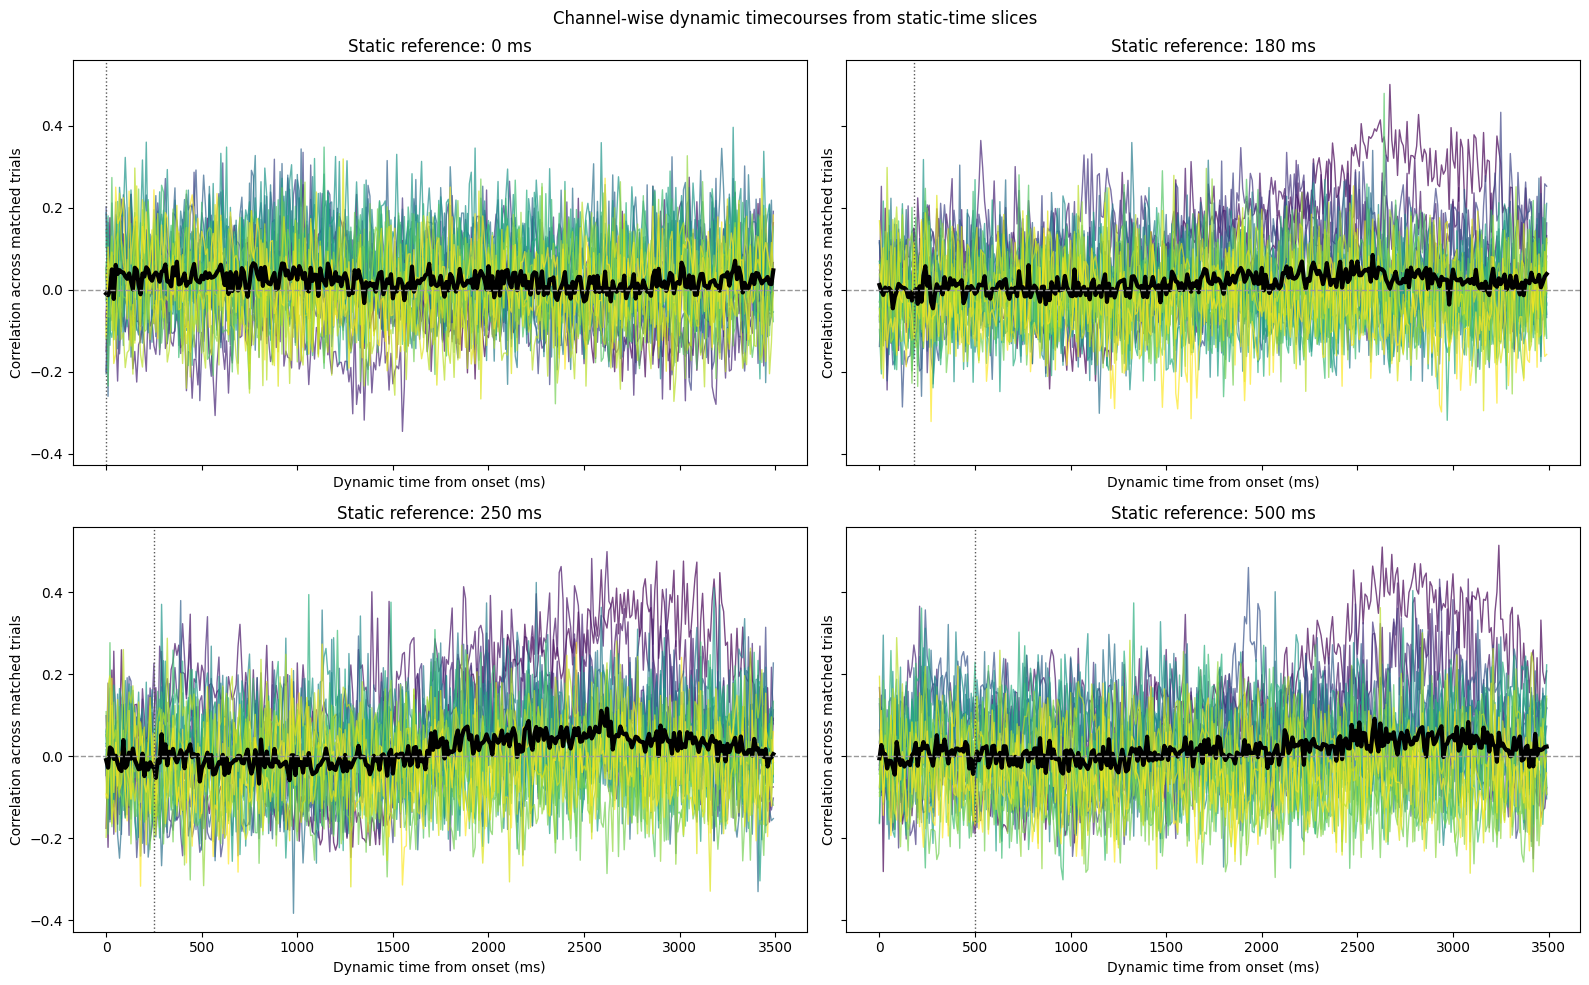

In [47]:
slice_indices = np.unique([
    np.argmin(np.abs(static_times_ms - requested_ms))
    for requested_ms in cfg.static_slice_ms
])
figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10),
    sharex=True,
    sharey=True,
)
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_numbers)))

for axis, static_index in zip(axes.flat, slice_indices, strict=False):
    slice_timecourses = channel_corr_matrices[:, :, static_index]
    for channel_index, channel_number in enumerate(channel_numbers):
        if selected_excitation_scores is None:
            channel_label = f"Ch {channel_number}"
        else:
            channel_label = f"#{channel_index + 1}: Ch {channel_number}"
        # end if selected_excitation_scores is None

        axis.plot(
            dynamic_times_ms,
            slice_timecourses[channel_index],
            color=colors[channel_index],
            alpha=0.7,
            linewidth=1,
            label=channel_label,
        )
    # end for channel_index, channel_number
    axis.plot(
        dynamic_times_ms,
        np.nanmean(slice_timecourses, axis=0),
        color="black",
        linewidth=3,
        label="Channel average",
    )
    axis.axhline(0, color="0.6", linestyle="--", linewidth=1)
    axis.axvline(
        static_times_ms[static_index],
        color="0.35",
        linestyle=":",
        linewidth=1,
    )
    axis.set(
        title=f"Static reference: {static_times_ms[static_index]:g} ms",
        xlabel="Dynamic time from onset (ms)",
        ylabel="Correlation across matched trials",
    )
# end for axis, static_index

# axes.flat[0].legend(fontsize="small", ncols=2)
figure.suptitle("Channel-wise dynamic timecourses from static-time slices")
figure.tight_layout()
plt.show()